<a href="https://colab.research.google.com/github/Skyler-bot-code/Bivariate-and-Multivariate-Linear-Regression-Analysis-and-Model-Depiction-/blob/main/bivariate_and_multivariate_linear_regression_of_california_housing_price_prediction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/california-housing-prices-dataset-clean-and-ml")

print("Path to dataset files:", path)

100%|██████████| 400k/400k [00:00<00:00, 30.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nalisha/california-housing-prices-dataset-clean-and-ml/versions/1


In [ ]:
import os
import pandas as pd

print("Files in the downloaded directory:", os.listdir(path))


df_house = pd.read_csv(os.path.join(path, 'housing.csv.csv')).sample(n=200)
df_house.head()

Files in the downloaded directory: ['housing.csv.csv']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10296,-117.87,33.92,14.0,4039.0,669.0,1905.0,670.0,6.3303,303000.0,<1H OCEAN
8372,-118.35,33.97,30.0,1548.0,330.0,757.0,349.0,3.8056,323800.0,<1H OCEAN
16296,-121.22,37.97,37.0,1514.0,337.0,1121.0,337.0,2.4010,58400.0,INLAND
3388,-118.35,34.22,19.0,9259.0,1653.0,3963.0,1595.0,5.9970,228700.0,<1H OCEAN
6353,-117.95,34.14,33.0,1943.0,440.0,1526.0,353.0,3.0380,137500.0,INLAND


In [ ]:
df_house.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,200.000000,200.000000,200.000000,200.000000,199.000000,200.000000,200.000000,200.000000,200.000000
mean,-119.534700,35.505900,28.100000,2891.970000,588.537688,1554.745000,539.845000,3.757794,207933.520000
std,2.028396,2.074292,12.511301,2659.491369,488.881539,1243.558038,427.735607,1.709328,111344.773579
min,-124.150000,32.580000,3.000000,161.000000,27.000000,100.000000,30.000000,1.196400,44500.000000
25%,-121.807500,33.857500,18.000000,1535.750000,320.500000,894.500000,306.250000,2.498175,124250.000000
50%,-118.435000,34.210000,27.000000,2256.000000,457.000000,1233.000000,433.500000,3.404650,185650.000000
75%,-118.027500,37.697500,38.000000,3286.250000,707.000000,1800.250000,637.750000,4.783900,276125.000000
max,-114.470000,40.590000,52.000000,23386.000000,4171.000000,10493.000000,3671.000000,10.185400,500001.000000


In [ ]:
df_house = df_house[['median_income','housing_median_age','median_house_value']]

# check if there is any data that is NAN in the entire dataframe

# save the row with nan in a variable
nan_row = df_house[df_house.isna().any(axis = 1)]

# remove the nan_row
df_house.drop(nan_row.index, inplace = True)

# verify that the nan_row is empty
# df_house[df_house.isna().any(axis = 1)] # This line is redundant after dropping

df_house.head()

,median_income,housing_median_age,median_house_value
10296,6.3303,14.0,303000.0
8372,3.8056,30.0,323800.0
16296,2.4010,37.0,58400.0
3388,5.9970,19.0,228700.0
6353,3.0380,33.0,137500.0


### Sampling Data for Visualization

To prevent performance issues and crashes when plotting a large number of data points, we will sample a subset of the `df_house` DataFrame. This reduces the amount of data processed by the plotting functions while still providing a representative view of the data distribution.

<function matplotlib.pyplot.show(close=None, block=None)>

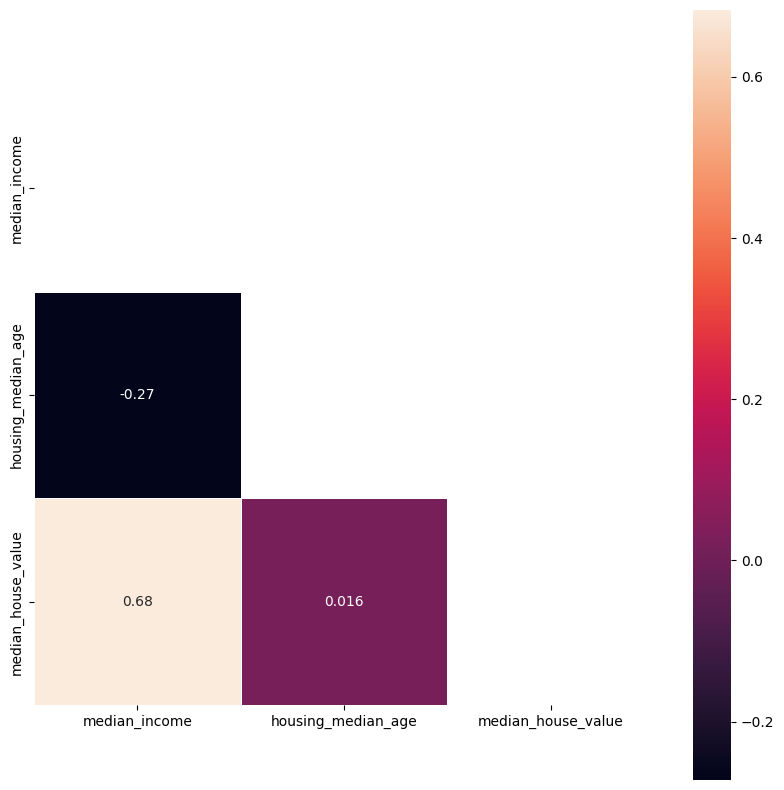

In [ ]:
# Checking whether there is a linear correlation between the three variables

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# compute the correlation coefficients

corr_coef = df_house.corr()

# plot the heatmap

plt.figure(figsize = (10,10))
# build a mask over half of the top heatmap
mask = np.zeros_like(corr_coef, dtype = bool)
mask[np.triu_indices_from(mask)] = True

# plot the heatmap with the mask
sns.heatmap(corr_coef, mask = mask, square = True, linewidth = 0.7, annot = True)
plt.show

Bivariate Linear Regression:

$$\large \text{Oxygen level (mm)} = \hat{b}_0 + \hat{m}\text{Salinity}+\hat{e}$$

In [ ]:
import plotly.graph_objects as go
import numpy as np
import statsmodels.formula.api as smf

# Bivariate linear regression with outliers

formula = "Q('median_house_value') ~ Q('median_income')"
model = smf.ols(formula, data = df_house)
reg_results_1 = model.fit()

print(reg_results_1.summary())

# Values of coefficent b and m of the model
[intercept, slope] = reg_results_1.params
print(f"intercept = {intercept: .3f} and the slope = {slope: .3f}")

# Fitted value
yhat = reg_results_1.fittedvalues

# residuals (Errors)
ehat = reg_results_1.resid

# Sum of squared errors
sse = sum(np.square(ehat))

# Standard Deviations
std = np.sqrt(sse / (len(ehat) - 2))



# Plot the linear regression line and mean of y + 2std above and below



fig = go.Figure() # opening a plotting area

# add a trace for the regression line
fig.add_trace(go.Scatter(
                        x = df_house["median_income"], # x = predictor
                        y = df_house["median_house_value"], # y = resond
                        mode = "markers",
                        name = "Actual",
                        marker = dict(color = "blue",
                                      symbol = "square-open",
                                      size = abs(ehat)/100000,
                                      sizemin = 4
                                      ),
                        hovertext = df_house.index,
                        error_y = dict(type = "data",
                                        symmetric = False,
                                        array = -ehat,
                                        color = "lightgreen",
                                        thickness = 1
                                        )

                        ))

fig.add_trace(go.Scatter(
                        x = df_house["median_income"], # x = predictor
                        y = yhat, # y = respond
                        mode = "lines",
                        name = "Predicted"

                        ))

# draw the boundaries for significant outliers

# mean of y + 2 * std above
fig.add_trace(go.Scatter(
                        x = df_house["median_income"], # x = predictor
                        y = yhat + 2 * std, # y = respond
                        mode = "lines",
                        line = dict(color = "orange", width = 2, dash = "dash"),
                        name = "Predicted + 2std"

                        ))
# mean of y + 2 * std below
fig.add_trace(go.Scatter(
                        x = df_house["median_income"], # x = predictor
                        y = yhat - 2 * std, # y = respond
                        mode = "lines",
                        line = dict(color = "orange", width = 2, dash = "dash"),
                        name = "Predicted - 2std"

                        ))


fig.update_layout(
                  height = 800, width = 1000,
                  title = f"Equation: median house value = {slope: .3f}(median income) + {intercept: .3f}",
                  title_x = 0.5,
                  xaxis_title = "Median income",
                  yaxis_title = "Median House Value",
                  font= dict(color = "green", size = 20)
                  )

                               OLS Regression Results                              
Dep. Variable:     Q('median_house_value')   R-squared:                       0.466
Model:                                 OLS   Adj. R-squared:                  0.464
Method:                      Least Squares   F-statistic:                     173.1
Date:                     Mon, 08 Jun 2026   Prob (F-statistic):           8.05e-29
Time:                             18:20:41   Log-Likelihood:                -2544.5
No. Observations:                      200   AIC:                             5093.
Df Residuals:                          198   BIC:                             5100.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [ ]:
# Identify the outliers for Bivariate Linear Regression (Forest Area and Renewable Energy)
import plotly.graph_objects as go
import numpy as np
import statsmodels.formula.api as smf

# identify where the outliers (yhat + 2std) are
outliers_above = df_house[df_house["median_house_value"] > (yhat + 2 * std)]
outliers_below = df_house[df_house["median_house_value"] < (yhat - 2 * std)]

print(f"Outliers 2 standard deviation above the regression line")
print(outliers_above)
print(f"Outliers 2 standard deviation below the regression line")
print(outliers_below)

# make a copy of the original dataframe

df_house_no_outlier = df_house.copy()

# remove the outliers
df_house_no_outlier.drop(outliers_above.index, inplace = True)
df_house_no_outlier.drop(outliers_below.index, inplace = True)

formula_no_outliers = "Q('median_house_value') ~ Q('median_income')"
model_no_outliers = smf.ols(formula_no_outliers, data = df_house_no_outlier)
reg_results_no_outliers = model_no_outliers.fit()

[intercept_no, slope_no] = reg_results_no_outliers.params # intercept and slope
ehat1 = reg_results_no_outliers.resid # residuals
yhat1 = reg_results_no_outliers.fittedvalues # values of dependent variable
sse1 = sum(np.square(ehat1)) #sum of square errors
std1 = np.sqrt(sse1 / (len(ehat1) - 2)) #standard deviation
print(f"intercept = {intercept_no: .3f} and the slope = {slope_no: .3f}")

fig = go.Figure() # opening a plotting area

# add a trace for the regression line
fig.add_trace(go.Scatter(
                        x = df_house_no_outlier["median_income"], # x = predictor
                        y = df_house_no_outlier["median_house_value"], # y = resond
                        mode = "markers",
                        name = "Actual",
                        marker = dict(color = "blue",
                                      symbol = "square-open",
                                      size = abs(ehat1)/100000,
                                      sizemin = 4
                                      ),
                        hovertext = df_house_no_outlier.index,
                        error_y = dict(type = "data",
                                        symmetric = False,
                                        array = -ehat1,
                                        color = "lightgreen",
                                        thickness = 1
                                        )

                        ))

fig.add_trace(go.Scatter(
                        x = df_house_no_outlier["median_income"], # x = predictor
                        y = yhat1, # y = respond
                        mode = "lines",
                        name = "Predicted"

                        ))

# draw the boundaries for significant outliers

# mean of y + 2 * std above
fig.add_trace(go.Scatter(
                        x = df_house_no_outlier["median_income"], # x = predictor
                        y = yhat1 + 2 * std1, # y = respond
                        mode = "lines",
                        line = dict(color = "orange", width = 2, dash = "dash"),
                        name = "Predicted + 2 * std"

                        ))
# mean of y + 2 * std below
fig.add_trace(go.Scatter(
                        x = df_house_no_outlier["median_income"], # x = predictor
                        y = yhat1 - 2 * std1, # y = respond
                        mode = "lines",
                        line = dict(color = "orange", width = 2, dash = "dash"),
                        name = "Predicted - 2 * std"

                        ))


fig.update_layout(
                  height = 800, width = 1000,
                  title = f"Equation: median house value = {slope_no: .3f}(Median income) + {intercept_no: .3f}",
                  title_x = 0.5,
                  xaxis_title = "Forest Area (%)",
                  yaxis_title = "CO2 Emissions (Tons/Capita)",
                  font= dict(color = "green", size = 20)
                  )

Outliers 2 standard deviation above the regression line
       median_income  housing_median_age  median_house_value
4710          2.6781                33.0            328800.0
8766          5.7361                39.0            500001.0
4734          3.0707                52.0            417900.0
15713         2.8569                52.0            372200.0
8286          4.1765                52.0            393900.0
5721          3.6875                47.0            422000.0
18292         4.9519                31.0            500001.0
10400         5.1360                15.0            447400.0
5298          2.2857                14.0            500001.0
4714          4.5192                52.0            446000.0
10766         3.2125                26.0            455000.0
Outliers 2 standard deviation below the regression line
      median_income  housing_median_age  median_house_value
2742         5.7843                 5.0            110100.0
intercept =  26015.851 and the slope

In [ ]:
print(reg_results_no_outliers.summary())

                               OLS Regression Results                              
Dep. Variable:     Q('median_house_value')   R-squared:                       0.630
Model:                                 OLS   Adj. R-squared:                  0.628
Method:                      Least Squares   F-statistic:                     317.2
Date:                     Mon, 08 Jun 2026   Prob (F-statistic):           4.70e-42
Time:                             18:59:39   Log-Likelihood:                -2335.1
No. Observations:                      188   AIC:                             4674.
Df Residuals:                          186   BIC:                             4681.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Analysis of Bivariate Regression results ##

With the outliers, the $p$ values of the intercept is nearly zero, and the slope is zero, which both are smaller than $\alpha = 0.05$, we reject the null hypothesis. The intercept and slope are statistically significant in this model. However, without the outliers, the intercept is greater than $\alpha$ = 0.05, meaning we would only include the slope for prediction.

Adjusted $R^2$ is a statitical measure of fit that indicates how much variation of a dependent variable is explained by the explanatory variable in this model. With the outlier, the model has 46.4% of the variations in the median house value that can be explained by median income. However, the model without the outlier has a higher adjusted $R^2$ of 62.8%, indicating that this model has a stronger explanatory power.

Two ways to predict:
* Include intercept in data with outlier: $\Large y = 44488.911x + 40753.3$
* Reject intercept in data without outlier (More accurate): $\Large y = 45208.358x$



F-statistic Analysis:

* In the model without the outliers, the F statistic is 317.2, with p value $4.70 \cdot 10^{-42} <<<<< \alpha = 0.05 = 5\cdot 10^{-2}$. We reject the null hypothesis that there is no relation between the median house value and median income, or the slope = 0 as the regression is a horizontal line. In other words, the model (slope) is statistically significant.




## Evaluation of Model Performances ##

### Evaluation of Model Assumptions

**Durbin-Watson Statistic:**
*   The Durbin-Watson statistic for `reg_results_no_outliers` is **2.030**. A value around 2 suggests no significant first-order serial correlation in the residuals. This indicates that the assumption of independent errors is likely met.

**Normality of the Residuals (Jarque-Bera Test):**
*   The Jarque-Bera test's `Prob(JB)` (p-value) for `reg_results_no_outliers` is **0.000954**. Since this p-value is less than $\alpha = 0.05$, we **reject the null hypothesis** that the residuals are normally distributed. This suggests that the residuals of this model are *not* normally distributed.

In [ ]:
# Scatter Plot with Actual Data and Fitted Value Comparison

import pandas as pd
import plotly.graph_objects as go

fig = go.Figure()

# plot the actual data
fig.add_trace(go.Scatter(
                         x = df_house_no_outlier["median_income"],
                         y = df_house_no_outlier["median_house_value"],
                         mode = "markers",
                         name = "Actual",
                         line_color = "green",
                         marker = dict(size = 5, color = "magenta", opacity = 0.3)
                        ))

# plot the fitted value
fig.add_trace(go.Scatter(
                         x = df_house_no_outlier["median_income"],
                         y = yhat1,
                         mode = "markers",
                         name = "Predicted",
                         line_color = "orange",
                         marker = dict(size = 5, color = "blue", opacity = 0.6)
                        ))


fig.update_layout(yaxis_title = "Median house value",
                  xaxis_title = "Income"
                  )
fig.show()

## Multivariate Linear Regression ##

$$\large\text{median_house_value} = \hat{b}_0+\hat{m}_1\text{median_income} + \hat{m}_2\text{housing_median_age}+e$$

In [ ]:
# Perform Multivariate Linear Regression
import statsmodels.formula.api as smf
import numpy as np

formula_multi = "Q('median_house_value') ~ Q('median_income') + Q('housing_median_age')"
model_multi = smf.ols(formula_multi, data = df_house)
reg_results_multi = model_multi.fit()

print(reg_results_multi.summary())

# Get coefficients and other metrics from the multivariate model
coef_multi = reg_results_multi.params
ehat_multi = reg_results_multi.resid
sse_multi = sum(np.square(ehat_multi))
std_multi = np.sqrt(sse_multi / (len(ehat_multi) - len(coef_multi)))

print(f"Multivariate model intercept = {coef_multi[0]: .3f}")
print(f"Coefficient for median income (%) = {coef_multi[1]: .3f}")
print(f"Coefficient for housing median age (%) = {coef_multi[2]: .3f}")
print(f"Standard deviation of residuals = {std_multi: .3f}")

                               OLS Regression Results                              
Dep. Variable:     Q('median_house_value')   R-squared:                       0.511
Model:                                 OLS   Adj. R-squared:                  0.506
Method:                      Least Squares   F-statistic:                     102.7
Date:                     Mon, 08 Jun 2026   Prob (F-statistic):           2.74e-31
Time:                             18:31:54   Log-Likelihood:                -2535.9
No. Observations:                      200   AIC:                             5078.
Df Residuals:                          197   BIC:                             5088.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

/tmp/ipykernel_13219/2109346759.py:17: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/2109346759.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/2109346759.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [ ]:
# Multivariate Regression Analysis
import plotly.graph_objects as go
import numpy as np

# Coefficients from the multivariate model
intercept_m = coef_multi[0]
slope_1 = coef_multi[1]
slope_2 = coef_multi[2]

print(f"The intercept is {intercept_m: .1f}")

fig = go.Figure()

# create a 2D grid for the independent variables
x_range = np.linspace(df_house["median_income"].min(), df_house["median_income"].max(), 100)
y_range = np.linspace(df_house["housing_median_age"].min(), df_house["housing_median_age"].max(), 100)

X_grid, Y_grid = np.meshgrid(x_range, y_range)

# create the coordinate for a 3d plane using multivariate coefficients
Z_plane = slope_1 * X_grid + slope_2 * Y_grid + intercept_m

# Add actual data points
fig.add_trace(
              go.Scatter3d(
                            x = df_house["median_income"],
                            y = df_house["housing_median_age"],
                            z = df_house["median_house_value"],
                            mode = "markers",
                            marker = dict(size = 4, color = "red", opacity = 0.5),
                            name = "Actual Data"
                          )
              )

# Add regression plane
fig.add_trace(go.Surface(
                         x = X_grid, y = Y_grid, z = Z_plane, colorscale = "blues", showscale = False,
                         name = "Regression Plane",
                         opacity = 0.6
                         )
              )

# Add plane for + 2 * std_multi
fig.add_trace(go.Surface(
                         x = X_grid, y = Y_grid, z = Z_plane + 2 * std_multi, colorscale = "viridis", showscale = False,
                         name = "Predicted + 2 * Std",
                         opacity = 0.3
                         )
              )

# Add plane for - 2 * std_multi
fig.add_trace(go.Surface(
                         x = X_grid, y = Y_grid, z = Z_plane - 2 * std_multi, colorscale = "viridis", showscale = False,
                         name = "Predicted - 2 * Std",
                         opacity = 0.3
                         )
              )

fig.update_layout(width = 1000, height = 700,
                  title = f"Equation: median house value = {slope_1: .3f}(median income) + {slope_2: .3f}(housing median age) + {intercept_m: .3f}",
                  title_x = 0.5,
                  scene = dict(
                               xaxis_title = "median income",
                               yaxis_title = "housing median age",
                               zaxis_title = "median house value"
                               )
                  )

fig.show()

The intercept is -28361.5


/tmp/ipykernel_13219/2913630846.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/2913630846.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/2913630846.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [ ]:
# Perform Multivariate Linear Regression on data without outliers
import statsmodels.formula.api as smf
import numpy as np

formula_multi_no_outliers = "Q('median_house_value') ~ Q('median_income') + Q('housing_median_age')"
model_multi_no_outliers = smf.ols(formula_multi_no_outliers, data = df_house_no_outlier)
reg_results_multi_no_outliers = model_multi_no_outliers.fit()

print(reg_results_multi_no_outliers.summary())

# Get coefficients and other metrics from the new multivariate model without outliers
coef_multi_no_outliers = reg_results_multi_no_outliers.params
ehat_multi_no_outliers = reg_results_multi_no_outliers.resid
sse_multi_no_outliers = sum(np.square(ehat_multi_no_outliers))
std_multi_no_outliers = np.sqrt(sse_multi_no_outliers / (len(ehat_multi_no_outliers) - len(coef_multi_no_outliers)))

print(f"Multivariate no-outliers model intercept = {coef_multi_no_outliers[0]: .3f}")
print(f"Coefficient for median income (no outliers) = {coef_multi_no_outliers[1]: .3f}")
print(f"Coefficient for housing median age (no outliers) = {coef_multi_no_outliers[2]: .3f}")
print(f"Standard deviation of residuals (no outliers) = {std_multi_no_outliers: .3f}")

                               OLS Regression Results                              
Dep. Variable:     Q('median_house_value')   R-squared:                       0.653
Model:                                 OLS   Adj. R-squared:                  0.649
Method:                      Least Squares   F-statistic:                     173.8
Date:                     Mon, 08 Jun 2026   Prob (F-statistic):           3.30e-43
Time:                             18:43:23   Log-Likelihood:                -2329.2
No. Observations:                      188   AIC:                             4664.
Df Residuals:                          185   BIC:                             4674.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

/tmp/ipykernel_13219/723323793.py:17: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/723323793.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/723323793.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [ ]:
import plotly.graph_objects as go
import numpy as np

# Coefficients from the multivariate model without outliers
intercept1 = coef_multi_no_outliers[0]
slope1 = coef_multi_no_outliers[1]
slope2 = coef_multi_no_outliers[2]
# ehat1 = reg_results_multi_no_outliers.resid # residuals (not directly used in this plot)
# yhat1 = reg_results_multi_no_outliers.fittedvalues # values of dependent variable (not directly used in this plot)
std1 = std_multi_no_outliers #standard deviation

print(f"Intercept = {intercept1: .3f}\nthe slope of median income = {slope1: .3f}\nthe slope of housing median age = {slope2: .3f}")

fig = go.Figure()

# create a 2D grid for the independent variables
x_range = np.linspace(df_house_no_outlier["median_income"].min(), df_house_no_outlier["median_income"].max(), 100)
y_range = np.linspace(df_house_no_outlier["housing_median_age"].min(), df_house_no_outlier["housing_median_age"].max(), 100)

X_grid, Y_grid = np.meshgrid(x_range, y_range)

# create the coordinate for a 3d plane using multivariate coefficients
Z_plane = slope1 * X_grid + slope2 * Y_grid + intercept1

# Add actual data points
fig.add_trace(
              go.Scatter3d(
                            x = df_house_no_outlier["median_income"],
                            y = df_house_no_outlier["housing_median_age"],
                            z = df_house_no_outlier["median_house_value"],
                            mode = "markers",
                            marker = dict(size = 4, color = "red", opacity = 0.5),
                            name = "Actual Data (No Outliers)"
                          )
              )

# Add regression plane
fig.add_trace(go.Surface(
                         x = X_grid, y = Y_grid, z = Z_plane, colorscale = "blues", showscale = False,
                         name = "Regression Plane (No Outliers)",
                         opacity = 0.6
                         )
              )

# Add plane for + 2 * std_multi
fig.add_trace(go.Surface(
                         x = X_grid, y = Y_grid, z = Z_plane + 2 * std1, colorscale = "viridis", showscale = False,
                         name = "Predicted + 2 * Std (No Outliers)",
                         opacity = 0.3
                         )
              )

# Add plane for - 2 * std_multi
fig.add_trace(go.Surface(
                         x = X_grid, y = Y_grid, z = Z_plane - 2 * std1, colorscale = "viridis", showscale = False,
                         name = "Predicted - 2 * Std (No Outliers)",
                         opacity = 0.3
                         )
              )

fig.update_layout(width = 1000, height = 700,
                  title = f"Equation: median_house_value = {slope1: .3f}(median_income) + {slope2: .3f}(housing_median_age) + {intercept1: .3f} (No Outliers)",
                  title_x = 0.5,
                  scene = dict(
                               xaxis_title = "Median Income",
                               yaxis_title = "Housing median Age",
                               zaxis_title = "Median house Value"
                               )
                  )

fig.show()

Intercept = -18770.133
the slope of median income =  47752.368
the slope of housing median age =  1274.538


/tmp/ipykernel_13219/363418708.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/363418708.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_13219/363418708.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Multivariate Linear Regression Analysis:

* After examiming the OLS Regression Result from both results with and without outliers, the p-value for intercepts from both results are greater than $\alpha$ = 0.05, meaning that it is insignificant to include in the model.

* By comparing the adjusted $R^2$ from both OLS Regression Results, the model without the outlier has a stronger explanatory power of 64.9%, which is higher than 50.6% from the regression model with the outliers.

* The p-value for both models in F-statistics are significantly lesser than $\alpha$ = 0.05, meaning the model is statistically significant.

* Predicted multivariated regression:


Evaluate the Model:

 $\Large y  = 47752.368m_{1} + 1274.538m_{2}$

* The table statistic value for the model without the outlier is 2.042, which is slightly greater than 2, meaning there is a slightly negative serial correlation in the residual.

Normality of the Residual:
* The Jarque-Bera test's `Prob(JB)` (p-value) for `reg_results_multi_no_outliers` is **0.000816**. Since this p-value is less than $\alpha = 0.05$, we **reject the null hypothesis** that the residuals are normally distributed. This suggests that the residuals of this multivariate model are *not* normally distributed.

In [ ]:
# Residuals (Errors) and Fits Plot

import pandas as pd
import plotly.graph_objects as go

fig = go.Figure()

# plot the actual data
fig.add_trace(go.Scatter(
                         x = yhat1,
                         y = ehat1,
                         mode = "markers",

                         line_color = "green",
                         marker = dict(size = 6, color = "blue", opacity = 0.3)
                        ))

fig.update_layout(
                  title = r"$\text{Residuals from the Regression Model}{\hat(e)}$",
                  title_x = 0.5,
                  font = dict(size = 18, color = "orange"),
                  xaxis_title = r"$\Large \text{Fitted values} (\hat{y})$",
                  yaxis_title = r"$\Large \text{Residuals (Errors)} (\hat{e})$",
                  width = 700, height = 500
                  )
fig.update_yaxes(
                  showgrid = False,
                  zeroline = True,
                  zerolinewidth = 3,
                  zerolinecolor = "yellow",
                  showticklabels = False
                )

fig.show()

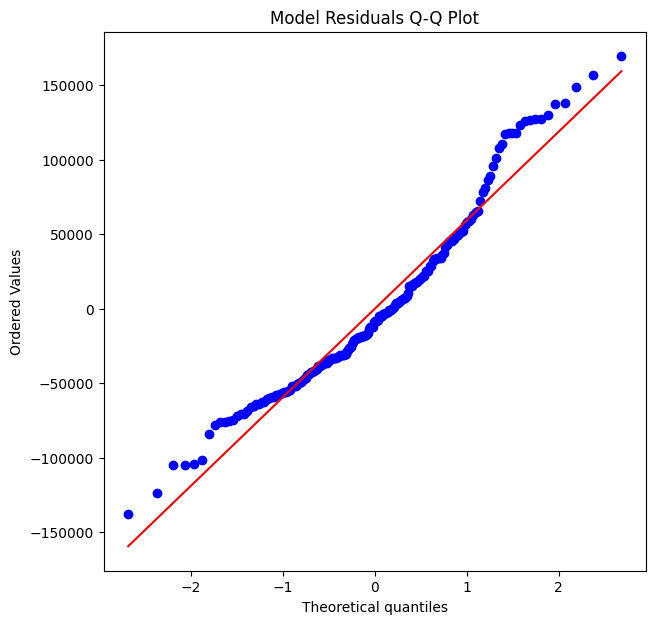

In [ ]:
# Q - Q Plot
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize = (7, 7))
stats.probplot(ehat1, dist = "norm", plot = plt)
plt.title("Model Residuals Q-Q Plot")
plt.show()

In [ ]:
# Assumptions of Homoscedasticity
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["Lagrange multiplier statistic", "p-value", "f-value", "p-value for f-value"]
test = sms.het_breuschpagan(ehat1, reg_results_no_outliers.model.exog)

lzip(name, test)

[('Lagrange multiplier statistic', np.float64(3.0891838992009526)),
 ('p-value', np.float64(0.07881432723282983)),
 ('f-value', np.float64(3.107380181255358)),
 ('p-value for f-value', np.float64(0.07958053415546594))]

Some p values > $\alpha = 0.05$, so we fail to reject the null hypothesis of the Breusch-Pagan test. Therefore, there is no statistically significant evidence of heteroscedasticity in the residuals. This suggests that the homoscedasticity assumption is satisfied.



### Summary of Homoscedasticity Findings

The analysis indicates that the assumption of **homoscedasticity is met** in the housing dataset. This is a positive finding because it ensures:

*   **Reliable Standard Errors and P-values**: The statistical significance of regression coefficients for `median_income` and `housing_median_age` can be confidently interpreted.
*   **Consistent Prediction Accuracy**: The model's predictions are uniformly accurate across different ranges of income and age.
*   **Efficient OLS Estimators**: The coefficients are estimated precisely, providing accurate insights into the relationships.

Overall, meeting this assumption strengthens the validity and generalizability of your findings on how `median_income` and `housing_median_age` influence `median_house_value`.